In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Electromagnetismo II
## Proyecto 1. Ecuación de Laplace en dos dimensiones
Nombre: **Ángel André Aguilar Contreras**

### Proyecto.

Genera un programa de cómputo (en el lenguaje de tu preferencia) que calcule numéricamente la solución a la ecuación de Laplace en dos dimensiones para un conjunto discreto de puntos, tal y como se muestra en la figura. Los puntos de la frontera exterior se encuentran a un potencial $\phi = 0$, mientras que los puntos de la frontera interna est´an a un potencial igual a $\phi = 100$.


In [48]:
''' 1. Definición de parámetros '''
N = 50                # Número de puntos en cada lado de la malla (N x N)
L = 1.0               # Longitud del dominio de la malla (L x L)
d = L / (N - 1)       # Espaciado de la malla (d)
tolerance = 1e-4      # Tolerancia para criterio de convergencia
max_iteration = 10000 # Límite de iteraciones

In [49]:
''' 2. Inicialización de la malla '''
phi = np.zeros((N,N))

In [50]:
''' 3. Definición de las condiciones de fronteras '''
phi_int = 100
phi_ext = 0

# Definición de la frontera interior
i_min_int = N // 4 
i_max_int = 3 * N // 4 
j_min_int = N // 4 
j_max_int = 3 * N // 4 

# Lados horizontales del rectángulo interno
phi[j_min_int, i_min_int:i_max_int + 1] = phi_int
phi[j_max_int, i_min_int:i_max_int + 1] = phi_int

# Lados verticales del rectángulo interno
phi[j_min_int:j_max_int + 1, i_min_int] = phi_int
phi[j_min_int:j_max_int + 1, i_max_int] = phi_int

# Definición de la frontera exterior
phi[0, :] = phi_ext
phi[N - 1, :] = phi_ext
phi[1:N - 1, 0] = phi_ext
phi[1:N - 1, N - 1] = phi_ext

In [ ]:
'''' 4. Aplicación del algoritmo de Relajación '''
for iter_count in range(max_iteration):
    prev_phi = phi.copy() # Generar una copia de la malla
    max_diff = 0.0

    # Iterar sobre los puntos INTERIORES (excluyendo todas las fronteras)
    for j in range(1, N - 1):
        for i in range(1, N - 1):
            
            # Verificar si el punto NO es una frontera interna
            if not (j >= j_min_int and j <= j_max_int and i >= i_min_int and i <= i_max_int and
                    (j == j_min_int or j == j_max_int or i == i_min_int or i == i_max_int)):
                
                # Ecuación de Diferencias Finitas (promedio de vecinos)
                phi[j, i] = 0.25 * (phi[j + 1, i] + phi[j - 1, i] +
                                    phi[j, i + 1] + phi[j, i - 1])
                
                # Actualizar el cambio máximo
                diff = abs(phi[j, i] - phi_viejo[j, i])
                if diff > max_diff:
                    max_diff = diff

    # Criterio de Convergencia
    if max_diff < TOLERANCIA:
        print(f"¡Convergencia alcanzada en {iter_count} iteraciones!")
        break
        
    if iter_count == MAX_ITER - 1:
        print(f"Advertencia: Máximo de {MAX_ITER} iteraciones alcanzado sin convergencia completa.")


Iniciando cálculo para una malla 50x50...
¡Convergencia alcanzada en 642 iteraciones!


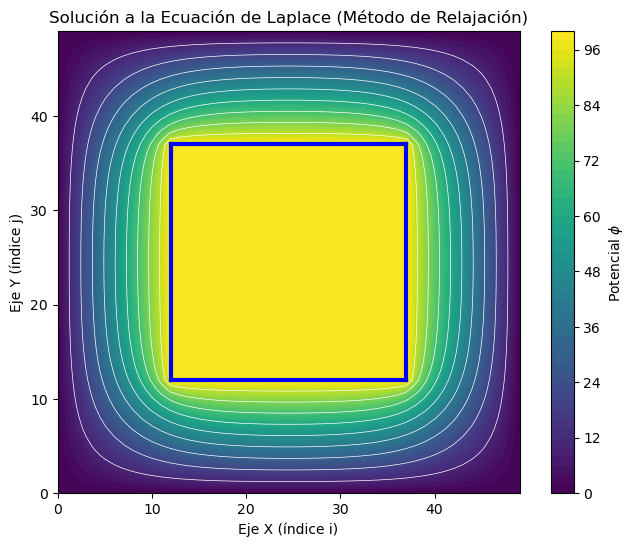

In [51]:

# --- 5. Visualización de Resultados ---
plt.figure(figsize=(8, 6))

# Mapa de calor del potencial
contour = plt.contourf(phi, cmap='viridis', levels=50) 
plt.colorbar(contour, label='Potencial $\phi$')

# Contornos para mejor detalle
plt.contour(phi, colors='white', linewidths=0.5, levels=[10, 20, 30, 40, 50, 60, 70, 80, 90])

# Resaltar las fronteras
plt.plot([i_min_int, i_max_int], [j_min_int, j_min_int], 'b-', linewidth=3)
plt.plot([i_min_int, i_max_int], [j_max_int, j_max_int], 'b-', linewidth=3)
plt.plot([i_min_int, i_min_int], [j_min_int, j_max_int], 'b-', linewidth=3)
plt.plot([i_max_int, i_max_int], [j_min_int, j_max_int], 'b-', linewidth=3)


plt.title('Solución a la Ecuación de Laplace (Método de Relajación)')
plt.xlabel('Eje X (índice i)')
plt.ylabel('Eje Y (índice j)')
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

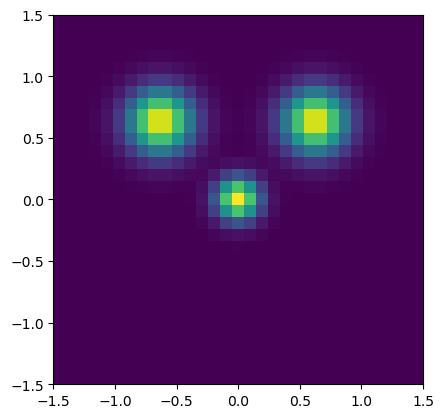

In [36]:
step = 0.1
side_length = 1.5
Y, X = np.mgrid[-side_length:side_length+step:step, -side_length:side_length+step:step]

X0 = [0, -0.65, 0.65]
Y0 = [0, -0.65, -0.65]
Sigma = np.array([0.03, 0.07, 0.07])

fig, ax = plt.subplots()

gaussians = np.zeros(X.shape)
for x0, y0, sigma in zip(X0, Y0, A):
    gaussians += gauss2D(X, Y, x0, y0, sigma)

ax.imshow(gaussians, extent=[-side_length, side_length, -side_length, side_length])

In [25]:
def gauss2D(X, Y, x0, y0, sigma):
    return np.exp(-((X - x0)**2 + (Y - y0)**2)/2*sigma**2)